# Comorbidity Pattern Mining and Patient Stratification in Texas Inpatient Hospital Data


**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

---


## Background Information

### Dataset: [Texas Inpatient PUDF](https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download)

### Scope
The Texas Inpatient Public Use Data File (PUDF) is a publicly available dataset covering inpatient visits across ~700 Texas hospitals over all four quarters of 2019. Inpatient visits are those where a physician has admitted a patient to a facility for extended monitoring or treatment, so each record represents a higher-acuity episode of care. With over 3 million records statewide, this analysis is scoped to the Bryan-College Station (BCS) area, 4 facilities in Bryan and 2 in College Station that reported data for all four quarters.

### Variables
Although the PUDF contains no patient-identifiable information, it provides rich per-visit records across 167 variables, including a principal diagnosis and up to 24 additional diagnoses, length of stay, total charges, insurance type, and patient demographics.

### ICD-10-CM Codes and CCSR
Diagnoses in the PUDF are recorded using ICD-10-CM (International Classification of Diseases, 10th Revision, Clinical Modification) codes, the standardized coding system used across U.S. healthcare to document conditions, symptoms, and findings. ICD-10-CM contains over 70,000 codes, making direct analysis of co-occurrence patterns sparse and difficult to interpret.

To address this, diagnoses are mapped to the Clinical Classifications Software Refined (CCSR), developed by the Agency for Healthcare Research and Quality (AHRQ). CCSR aggregates ICD-10-CM codes into ~530 clinically meaningful categories, for example collapsing all hypertension codes into a single "Hypertensive disease" category. This dimensionality reduction yields denser co-occurrence patterns and results that are more interpretable without sacrificing clinical relevance.

---

## Research Direction

### Comorbidities and Healthcare Resource Utilization
Co-morbidities is the co-occurrence of multiple diseases or conditions in a single patient. This can be something as straight-forward as diabetes and heart disease, or a combination of two very distinct conditions, like one mental health and one physical disorder. These patterns of multiple conditions can cause increasingly worse health outcomes and increased healthcare costs for patients. Because this dataset contains up to 25 diagnoses codes per patient, this is a meaningful clinical topic that could easily be explored in this dataset.

### Comorbidity as a Driver of Healthcare Costs
Prior research has established that patients with multiple concurrent conditions incur substantially higher healthcare expenditures than those with a single diagnosis (Wolff, Starfield & Anderson, 2002). Our working theory extends the finding that the relationship between comorbidity and cost is not uniform across all multi-condition patients. Rather, specific clusters of patients sharing similar combinations of diagnoses, should serve as strong predictors of high inpatient charges. If such subgroups exist and carry systematically elevated costs, identifying them could inform targeted care management and resource allocation strategies.

### Research Questions
1. Which diagnosis codes most commonly co-occur in BCS inpatient visits, and do any unexpected associations emerge?
2. What distinct patient subgroups share similar comorbidity profiles among inpatients in the BCS area?
3. Which comorbidity subgroups are the strongest predictors of high charges?

## Dataset and Initial Cleaning


### Setup

Dependencies are listed in `requirements.txt`. Key libraries used throughout this notebook:

| Library | Purpose |
|---|---|
| `pandas` / `numpy` | Data wrangling and numerical operations |
| `matplotlib` / `seaborn` | Plotting and visualization |
| `icdmappings` | ICD-10-CM → CCSR code translation |
| `mlxtend` | Apriori algorithm and association rule mining |
| `scikit-learn` / `scikit-learn-extra` | Clustering algorithms and evaluation metrics |
| `hdbscan` | Density-based hierarchical clustering |
| `scipy` | Pairwise distance and similarity computations |
| `umap-learn` | Dimensionality reduction for cluster visualization |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

from icdmappings import Mapper
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import MultiLabelBinarizer

from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import silhouette_score, roc_auc_score
from scipy.spatial.distance import pdist, squareform
import umap

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('Imports complete.')

Imports complete.


### Loading the Data

The BCS inpatient dataset was pre-filtered from the statewide Texas PUDF to retain only records from the 6 Bryan–College Station facilities that reported data across all four quarters of 2019. The CSV is loaded directly from Google Drive.

In [2]:
DATA_PATH = "/Users/stelladong/Library/CloudStorage/GoogleDrive-ssdong@tamu.edu/My Drive/bcs_tx_inpatient.csv"

bcs_tx_inpatient = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {bcs_tx_inpatient.shape[0]:,} rows × {bcs_tx_inpatient.shape[1]} columns")
print(f"\nColumn preview:\n{list(bcs_tx_inpatient.columns[:50])} ...")


Loaded: 12,179 rows × 169 columns

Column preview:
['Unnamed: 0', 'RECORD_ID', 'DISCHARGE', 'THCIC_ID', 'TYPE_OF_ADMISSION', 'SOURCE_OF_ADMISSION', 'SPEC_UNIT_1', 'SPEC_UNIT_2', 'SPEC_UNIT_3', 'SPEC_UNIT_4', 'SPEC_UNIT_5', 'PAT_STATE', 'PAT_ZIP', 'PAT_COUNTRY', 'PAT_COUNTY', 'PUBLIC_HEALTH_REGION', 'PAT_STATUS', 'SEX_CODE', 'RACE', 'ETHNICITY', 'ADMIT_WEEKDAY', 'LENGTH_OF_STAY', 'PAT_AGE', 'FIRST_PAYMENT_SRC', 'SECONDARY_PAYMENT_SRC', 'TYPE_OF_BILL', 'TOTAL_CHARGES', 'TOTAL_NON_COV_CHARGES', 'TOTAL_CHARGES_ACCOMM', 'TOTAL_NON_COV_CHARGES_ACCOMM', 'TOTAL_CHARGES_ANCIL', 'TOTAL_NON_COV_CHARGES_ANCIL', 'ADMITTING_DIAGNOSIS', 'PRINC_DIAG_CODE', 'POA_PRINC_DIAG_CODE', 'OTH_DIAG_CODE_1', 'POA_OTH_DIAG_CODE_1', 'OTH_DIAG_CODE_2', 'POA_OTH_DIAG_CODE_2', 'OTH_DIAG_CODE_3', 'POA_OTH_DIAG_CODE_3', 'OTH_DIAG_CODE_4', 'POA_OTH_DIAG_CODE_4', 'OTH_DIAG_CODE_5', 'POA_OTH_DIAG_CODE_5', 'OTH_DIAG_CODE_6', 'POA_OTH_DIAG_CODE_6', 'OTH_DIAG_CODE_7', 'POA_OTH_DIAG_CODE_7', 'OTH_DIAG_CODE_8'] ...


### Patient Demographics

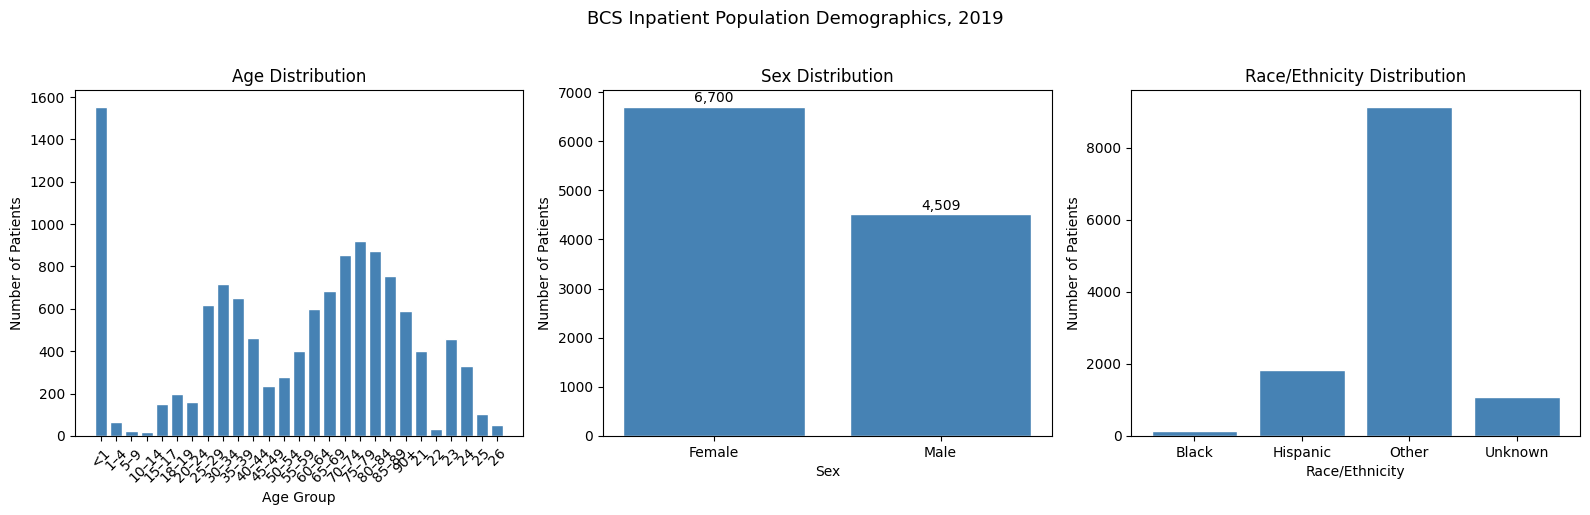

In [3]:
# --- Patient demographics: age, sex, race distributions ---
AGE_LABELS = {
    0: '<1', 1: '1–4', 2: '5–9', 3: '10–14', 4: '15–17', 5: '18–19',
    6: '20–24', 7: '25–29', 8: '30–34', 9: '35–39', 10: '40–44',
    11: '45–49', 12: '50–54', 13: '55–59', 14: '60–64', 15: '65–69',
    16: '70–74', 17: '75–79', 18: '80–84', 19: '85–89', 20: '90+',
}
RACE_LABELS = {1: 'White', 2: 'Black', 3: 'Hispanic', 4: 'Other', 5: 'Unknown'}
SEX_LABELS  = {'F': 'Female', 'M': 'Male'}

age_counts  = (bcs_tx_inpatient['PAT_AGE']
               .value_counts().sort_index()
               .rename(index=lambda x: AGE_LABELS.get(x, str(x))))
sex_counts  = (bcs_tx_inpatient['SEX_CODE']
               .value_counts()
               .rename(index=lambda x: SEX_LABELS.get(x, str(x))))
race_counts = (bcs_tx_inpatient['RACE']
               .value_counts().sort_index()
               .rename(index=lambda x: RACE_LABELS.get(x, str(x))))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(sex_counts.index, sex_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Sex Distribution')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Number of Patients')
for bar, val in zip(axes[1].patches, sex_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

axes[2].bar(race_counts.index, race_counts.values, color='steelblue', edgecolor='white')
axes[2].set_title('Race/Ethnicity Distribution')
axes[2].set_xlabel('Race/Ethnicity')
axes[2].set_ylabel('Number of Patients')

fig.suptitle('BCS Inpatient Population Demographics, 2019', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Although we are not given patient identifying information, we're given sufficient information about the patient demographics that we can make a few observations about this dataset before we start working with it:

* **<1 month anomaly:** From the age distribution, we can see that by far, the most frequent age group is patients <1 month old. This tells us that we will see a lot of either delivery/maternity related visits, or neonatal related visits. From the female-skewed distribution for gender, we can support that observation. 
* **Bi-modal age distribution:** The other pattern that we can see in the age distribution is that there are two other peaks in the distribution, one at age 20-24 and the other at age 65-69. The first is likely due to the large population of college-aged students in the region, and the other is more expected in inpatient care, older patients whose health starts to decline as they age.

### Total Charges

/var/folders/23/h9ybdrzn0vd4_fgl2z03prbm0000gn/T/ipykernel_10162/4033834326.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(charge_data, labels=charge_labels, showfliers=True, vert=False)


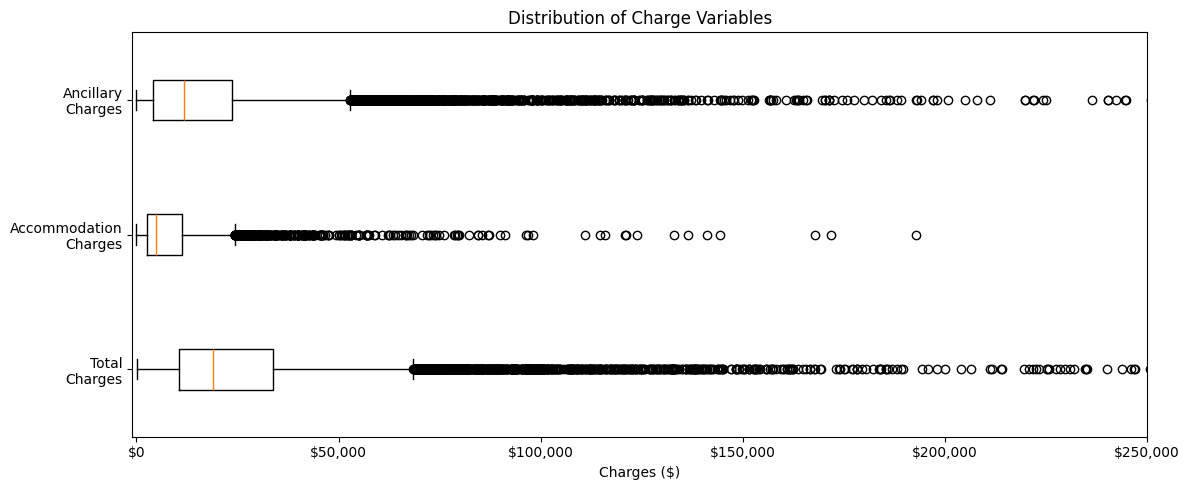

In [4]:
# --- Boxplots of charge variables ---
charge_cols = [
    'TOTAL_CHARGES',
    'TOTAL_CHARGES_ACCOMM',
    'TOTAL_CHARGES_ANCIL',
]

charge_labels = [
    'Total\nCharges',
    'Accommodation\nCharges',
    'Ancillary\nCharges',
]

charge_data = [bcs_tx_inpatient[c].dropna() for c in charge_cols]

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(charge_data, labels=charge_labels, showfliers=True, vert=False)
ax.set_xlabel('Charges ($)')
ax.set_title('Distribution of Charge Variables')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xlim(-1000, 250_000)
plt.tight_layout()
plt.show()

Charge distributions in this dataset are highly right-skewed: the IQR boxes sit well below \$25,000 for all variables, yet outliers extend far beyond \$100,000. As expected, the total charges are the widest spread as they aggregate accommodation (room, board, nursing) and ancillary (labs, imaging, pharmacy) components. Accommodation charges tend to be lower and tighter, while ancillary charges reach further into the tail, reflecting the cost of high-acuity diagnostic and treatment activity.

This skew is central to the project's motivation. Because most visits are relatively inexpensive while a small subset drives extreme costs, identifying which patients land in that tail is clinically and financially meaningful. If specific comorbidity subgroups are disproportionately represented among high-charge visits, then comorbidity profile becomes a tractable predictor of cost burden, which is exactly the hypothesis this project sets out to test.

### ICD-10-CM to CCSR Mapping

Each of the 25 possible diagnosis columns is mapped from its raw ICD-10-CM code to a CCSR category using the `icdmappings` library. Codes that cannot be mapped (e.g., malformed entries or codes not present in the CCSR reference) are dropped. Mapping is performed in batches over only the unique codes observed in the dataset to avoid redundant lookups.

This step reduces the raw ICD-10-CM space (70 000+ codes) to ~530 clinically meaningful CCSR categories, yielding denser co-occurrence patterns that are easier to mine and interpret.

In [5]:
df = bcs_tx_inpatient.copy()

# Identify diagnosis columns present in the dataframe
DIAG_COLS = [c for c in
             ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
             if c in df.columns]

# Collect all unique ICD-10 codes across all diagnosis columns
all_codes = set()
for col in DIAG_COLS:
    all_codes.update(df[col].dropna().unique())
all_codes = list(all_codes)
print(f"Unique ICD-10-CM codes in dataset: {len(all_codes):,}")

# Map each unique ICD-10-CM code to its CCSR category in batches
BATCH_SIZE = 10_000
mapper = Mapper()
ccsr_mapping = {}

for i in range(0, len(all_codes), BATCH_SIZE):
    batch = all_codes[i : i + BATCH_SIZE]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        ccsr_mapping[code] = ccsr  # None if unmappable

mapped = sum(1 for v in ccsr_mapping.values() if v is not None)
unique_ccsr = len(set(v for v in ccsr_mapping.values() if v is not None))
print(f"Successfully mapped: {mapped:,} / {len(ccsr_mapping):,} codes "
      f"({mapped / len(ccsr_mapping) * 100:.1f}%)")
print(f"Unique CCSR categories: {unique_ccsr:,}  "
      f"(reduced from {len(all_codes):,} ICD-10-CM codes, "
      f"{len(all_codes) / unique_ccsr:.0f}× reduction)")

Unique ICD-10-CM codes in dataset: 5,512
Successfully mapped: 5,512 / 5,512 codes (100.0%)
Unique CCSR categories: 440  (reduced from 5,512 ICD-10-CM codes, 13× reduction)


In [6]:
def get_ccsr_set(row):
    cats = set()
    for col in DIAG_COLS:
        code = row[col]
        if pd.notna(code):
            ccsr = ccsr_mapping.get(code)
            if ccsr is not None:
                cats.add(ccsr)
    return list(cats)

# Build list-of-lists: one entry per patient
ccsr_lists = df.apply(get_ccsr_set, axis=1).tolist()

## Research Question 1: Which diagnosis codes most commonly co-occur?

This section mines comorbidity patterns from the BCS inpatient dataset using the Apriori algorithm applied to CCSR-encoded patient visits. The goal is to identify pairs (or larger sets) of diagnosis categories that co-occur more often than expected by chance.

---

### Exploratory Data Analysis

Before mining association rules, we explore the diagnosis structure of the dataset: how many codes are recorded per visit, and which CCSR categories appear most frequently. This motivates the choice of support threshold and highlights the most prevalent conditions in the BCS inpatient population.

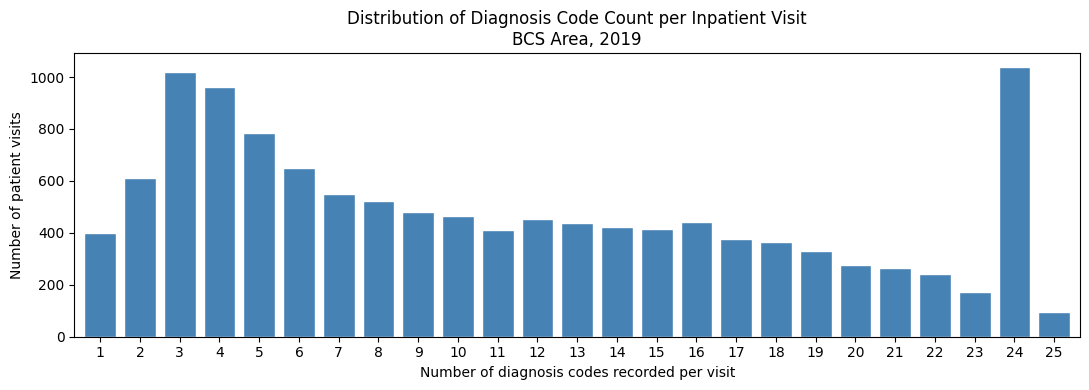

Mean diagnoses per visit  : 11.1
Median                    : 10
Max                       : 25
Visits with ≥ 2 diagnoses : 11,781  (96.7%)


In [7]:
# --- Distribution of diagnosis count per patient visit ---
diag_counts = df[DIAG_COLS].notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
diag_counts.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', width=0.8)
ax.set_xlabel("Number of diagnosis codes recorded per visit")
ax.set_ylabel("Number of patient visits")
ax.set_title("Distribution of Diagnosis Code Count per Inpatient Visit\nBCS Area, 2019")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(f"Mean diagnoses per visit  : {diag_counts.mean():.1f}")
print(f"Median                    : {int(diag_counts.median())}")
print(f"Max                       : {int(diag_counts.max())}")
print(f"Visits with ≥ 2 diagnoses : {(diag_counts >= 2).sum():,}  ({(diag_counts >= 2).mean()*100:.1f}%)")

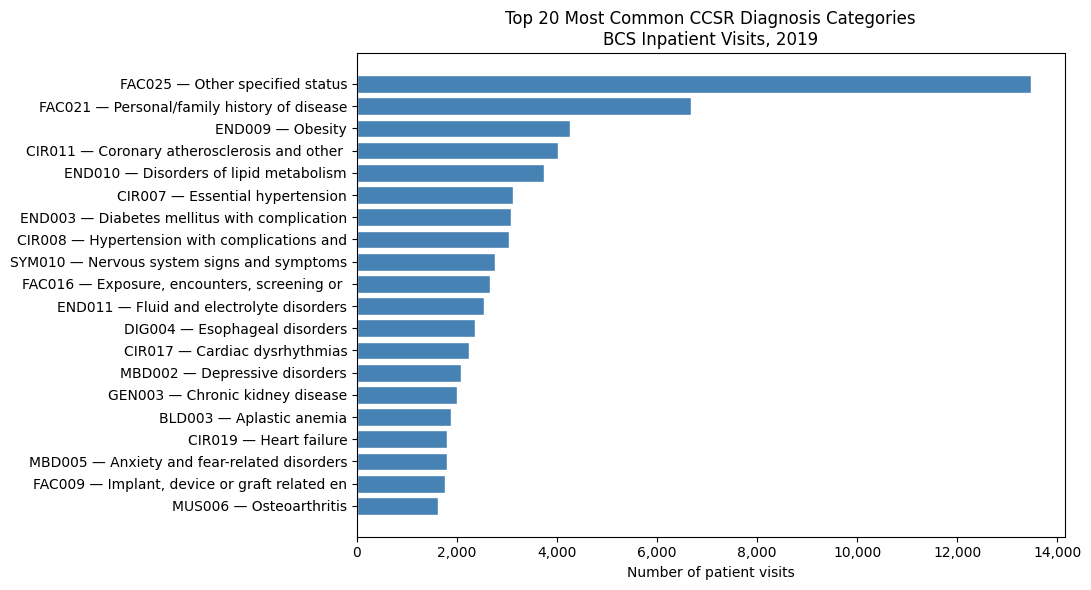

In [8]:
# --- Top 20 most common CCSR categories ---
CCSR_DESC_PATH = "/Users/stelladong/Documents/GitHub/676_project/ccsr_descriptions.txt"
ccsr_desc = {}
with open(CCSR_DESC_PATH) as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            ccsr_desc[parts[0]] = parts[1]

ccsr_counter = Counter()
for col in DIAG_COLS:
    for code in df[col].dropna():
        ccsr = ccsr_mapping.get(code)
        if ccsr is not None:
            ccsr_counter[ccsr] += 1

top20 = pd.DataFrame(ccsr_counter.most_common(20), columns=['ccsr', 'count'])
top20['label'] = top20['ccsr'].apply(
    lambda c: f"{c} — {ccsr_desc.get(c, c)[:35]}"
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20['label'][::-1], top20['count'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel("Number of patient visits")
ax.set_title("Top 20 Most Common CCSR Diagnosis Categories\nBCS Inpatient Visits, 2019")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### Common Diagnosis Categories

Over 96% of inpatient visits have more than one recorded diagnosis, confirming that comorbidity is the rule rather than the exception in this population. The median visit carries multiple distinct CCSR conditions, which justifies applying association rule mining rather than treating diagnoses in isolation.

 The top 20 CCSR categories reveal three dominant groups:

- Cardiovascular-metabolic cluster: Essential hypertension (CIR007), hypertension with complications (CIR008), coronary atherosclerosis (CIR011), heart failure (CIR019), disorders of lipid metabolism (END010), and diabetes mellitus with complications (END003) all rank among the most common categories. These conditions are well-known to co-occur.

- Chronic disease management codes: Categories such as chronic kidney disease (GEN003) and FAC025, a catch-all for chronic disease monitoring flags like long-term medication usem appear frequently as secondary diagnoses, indicating that many admissions involve patients managing multiple long-term conditions alongside their primary presenting complaint.

- Mental health disorder codes: Depressive disorders (MDB002) and anxiety and fear-related disorders (MBD005) are also present in the top 20 categories, although less high on the list than the other major groups. 

### Association Rule Mining

Association rule mining treats each patient visit as a "basket" of CCSR categories and searches for rules of the form *A → B* — if a patient has condition A, they also tend to have condition B. 

The Apriori algorithm is used with `min_support = 0.05` (at least 5% of visits) and `min_confidence = 0.50`.

In [9]:
# Reuse ccsr_lists computed during binary encoding
ccsr_transactions = [t for t in ccsr_lists if len(t) > 0]
print(f"Transactions : {len(ccsr_transactions):,} patients")
print(f"Avg CCSR categories per patient: {np.mean([len(t) for t in ccsr_transactions]):.1f}")

# Encode as a boolean DataFrame required by mlxtend
te = TransactionEncoder()
te_array = te.fit_transform(ccsr_transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f"Unique CCSR categories in transactions: {df_te.shape[1]}")

# --- Frequent itemsets ---
MIN_SUPPORT = 0.05      # at least 5% of patients
frequent_itemsets = apriori(df_te, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
print(f"\nFrequent itemsets (support ≥ {MIN_SUPPORT}): {len(frequent_itemsets):,}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10).to_string(index=False))

# --- Association rules ---
MIN_CONFIDENCE = 0.5
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"\nAssociation rules (confidence ≥ {MIN_CONFIDENCE}): {len(rules):,}")

Transactions : 12,179 patients
Avg CCSR categories per patient: 9.1
Unique CCSR categories in transactions: 440

Frequent itemsets (support ≥ 0.05): 306
 support         itemsets  length
0.496100         (FAC025)       1
0.377289         (FAC021)       1
0.296083         (END010)       1
0.271040 (FAC021, FAC025)       2
0.256507         (CIR007)       1
0.237376         (CIR008)       1
0.235816 (END010, FAC025)       2
0.196486 (FAC025, CIR008)       2
0.196157         (END009)       1
0.189342         (CIR011)       1

Association rules (confidence ≥ 0.5): 559


### Top Comorbidity Rules

Rules are ranked by lift, the ratio of observed co-occurrence to what would be expected if the two conditions were independent. A lift of 1.0 means no association; higher values indicate increasingly strong co-occurrence beyond chance. Rules with lift ≥ 2.0 are considered strong associations and are highlighted for further analysis.

Inspecting the top rules by lift immediately reveals that the highest-scoring associations (lift ~7.9–8.1) are dominated by pregnancy-related (PRG) and perinatal/neonatal (PNL) codes. For example, PRG002 (Gestational weeks) + PRG026 (OB-related trauma) precedes PRG030 (Maternal outcome of delivery) with a lift of 8.09

These are not clinically interesting comorbidities, they simply co-occur by definition within obstetric and neonatal admissions, where multiple obstetric codes are routinely co-assigned to the same visit. Their high lift reflects the structural coding conventions of labor and delivery records, not a meaningful disease association.

In [10]:
def describe_set(frozen_set):
    return ' | '.join(f"{c}: {ccsr_desc.get(c, c)}" for c in sorted(frozen_set))

# Filter to high-lift rules and add human-readable labels
HIGH_LIFT = 2.0
high_score_rules = rules[rules['lift'] >= HIGH_LIFT].copy()

high_score_rules['antecedent_codes']  = high_score_rules['antecedents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['antecedent_labels'] = high_score_rules['antecedents'].apply(describe_set)
high_score_rules['consequent_codes']  = high_score_rules['consequents'].apply(lambda s: ' | '.join(sorted(s)))
high_score_rules['consequent_labels'] = high_score_rules['consequents'].apply(describe_set)

export_cols = [
    'antecedent_codes', 'antecedent_labels',
    'consequent_codes', 'consequent_labels',
    'support', 'confidence', 'lift',
]
export_df = (high_score_rules[export_cols]
             .sort_values('lift', ascending=False)
             .reset_index(drop=True))
export_df[['support', 'confidence', 'lift']] = export_df[['support', 'confidence', 'lift']].round(4)

print(f"High-scoring rules (lift ≥ {HIGH_LIFT}): {len(export_df):,}\n")
display(export_df.head(15))

High-scoring rules (lift ≥ 2.0): 346



,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,PRG002 | PRG026,PRG002: Gestational weeks | PRG026: OB-related...,PRG030,PRG030: Maternal outcome of delivery,0.0525,1.0000,8.0870
1,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0525,0.9938,8.0797
2,PRG026,PRG026: OB-related trauma to perineum and vulva,PRG030,PRG030: Maternal outcome of delivery,0.0528,0.9984,8.0744
3,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,PRG030,PRG030: Maternal outcome of delivery,0.0669,0.9927,8.0279
4,PRG030,PRG030: Maternal outcome of delivery,PRG002 | PRG023,PRG002: Gestational weeks | PRG023: Complicati...,0.0669,0.5412,8.0279
5,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,PRG023,PRG023: Complications specified during childbirth,0.0669,0.5441,8.0122
6,PRG023,PRG023: Complications specified during childbirth,PRG002 | PRG030,PRG002: Gestational weeks | PRG030: Maternal o...,0.0669,0.9855,8.0122
7,PRG030,PRG030: Maternal outcome of delivery,PRG023,PRG023: Complications specified during childbirth,0.0672,0.5438,8.0088
8,PRG023,PRG023: Complications specified during childbirth,PRG030,PRG030: Maternal outcome of delivery,0.0672,0.9903,8.0088
9,PNL001,PNL001: Liveborn,FAC016 | PNL007,"FAC016: Exposure, encounters, screening or con...",0.0874,0.7060,7.9989


### Filtering PRG/PNL Codes

Because obstetric and neonatal codes co-occur by administrative coding convention rather than clinical comorbidity, rules where both the antecedent and consequent consist entirely of PRG or PNL codes are removed. Of the 346 high-lift rules (lift ≥ 2.0), 23 are removed, leaving 323 rules that reflect genuine disease co-occurrence patterns.

In [11]:
# --- Export rules excluding those where PRG/PNL codes appear on BOTH sides ---
# PRG = pregnancy-related, PNL = perinatal/neonatal — rules where both antecedent
# and consequent are purely obstetric/neonatal are clinically uninteresting.

def has_prg_or_pnl(frozen_set):
    return any(c.startswith('PRG') or c.startswith('PNL') for c in frozen_set)

mask = ~(high_score_rules['antecedents'].apply(has_prg_or_pnl) &
         high_score_rules['consequents'].apply(has_prg_or_pnl))
filtered_rules = high_score_rules[mask].copy()

export_df_filtered = (filtered_rules[export_cols]
                      .sort_values('lift', ascending=False)
                      .reset_index(drop=True))
export_df_filtered[['support', 'confidence', 'lift']] = (
    export_df_filtered[['support', 'confidence', 'lift']].round(4)
)

OUT_PATH = "/Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv"
export_df_filtered.to_csv(OUT_PATH, index=False)

print(f"Rules before filter : {len(export_df):,}")
print(f"Rules after filter  : {len(export_df_filtered):,}  (removed {len(export_df)-len(export_df_filtered):,} PRG/PNL-only rules)")
print(f"Saved → {OUT_PATH}\n")
display(export_df_filtered.head(15))

Rules before filter : 346
Rules after filter  : 323  (removed 23 PRG/PNL-only rules)
Saved → /Users/stelladong/Documents/GitHub/676_project/comorbidity_rules_no_prg_pnl.csv



,antecedent_codes,antecedent_labels,consequent_codes,consequent_labels,support,confidence,lift
0,CIR008 | END003,CIR008: Hypertension with complications and se...,END010 | FAC025 | GEN003,END010: Disorders of lipid metabolism | FAC025...,0.0504,0.5121,6.0493
1,END010 | FAC025 | GEN003,END010: Disorders of lipid metabolism | FAC025...,CIR008 | END003,CIR008: Hypertension with complications and se...,0.0504,0.5955,6.0493
2,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011 | FAC025,CIR008: Hypertension with complications and se...,0.0515,0.5806,5.9317
3,CIR008 | CIR011 | FAC025,CIR008: Hypertension with complications and se...,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,0.0515,0.5260,5.9317
4,CIR019 | END010 | FAC025,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011,CIR008: Hypertension with complications and se...,0.0515,0.6786,5.9200
5,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,CIR008 | CIR011,CIR008: Hypertension with complications and se...,0.0601,0.6778,5.9131
6,CIR008 | CIR011,CIR008: Hypertension with complications and se...,CIR019 | END010,CIR019: Heart failure | END010: Disorders of l...,0.0601,0.5244,5.9131
7,END010 | GEN003,END010: Disorders of lipid metabolism | GEN003...,CIR008 | END003,CIR008: Hypertension with complications and se...,0.0564,0.5682,5.7720
8,CIR008 | END003,CIR008: Hypertension with complications and se...,END010 | GEN003,END010: Disorders of lipid metabolism | GEN003...,0.0564,0.5730,5.7720
9,CIR008 | END003 | FAC025,CIR008: Hypertension with complications and se...,END010 | GEN003,END010: Disorders of lipid metabolism | GEN003...,0.0504,0.5680,5.7217


### Key Observations

**Research Question 1: Which diagnosis codes most commonly co-occur?**

Before filtering, the highest-lift associations in the dataset are pregnancy-related (PRG) and perinatal/neonatal (PNL) codes. After removing rules where both sides are purely obstetric/neonatal, the strongest genuine comorbidity associations center on a tight cluster of cardiometabolic disorders. The top-ranked rule by lift is the bidirectional association between {CIR008 (Hypertension w/ complications) + END003 (Diabetes w/ complication)} and {END010 (Disorders of lipid metabolism) + GEN003 (Chronic kidney disease) + FAC025 (Other specified status)} (lift = 6.05).

Nearly every rule with a lift over 2.0 involves some combination of the same group of cardiovascular and metabolic conditions: hypertension with complications (CIR008), disorders of lipid metabolism (END010), diabetes mellitus with complications (END003), chronic kidney disease (GEN003), coronary atherosclerosis (CIR011), and heart failure (CIR019). FAC025 (Other specified status), which is a catch-all for patients on long-term medications or chronic disease management, appears throughout as a co-occurring marker. This is consistent with the clinical concept of metabolic syndrome, where insulin resistance links hypertension, dyslipidemia, and diabetes, each of which progressively drives cardiovascular and renal damage.

Beyond the cardiometabolic core, including a few digestive (DIG) and respiratory (RSP) codes, appear only at lower lift values and in very few rules, suggesting that comorbidity burden in this BCS inpatient population is heavily concentrated in chronic metabolic and cardiovascular disease.

These findings directly reflect the cost dynamic that motivates this analysis. The cardiometabolic cluster dominating the association rules, including hypertension, diabetes, dyslipidemia, chronic kidney disease, and heart failure, represents exactly the kind of multi-condition burden that drives disproportionate healthcare expenditure. Wolff et al. (2002) found that patients with multiple chronic conditions account for the majority of Medicare spending, with costs rising steeply as the number of conditions increases. The tight co-occurrence of these diagnoses means patients rarely present with just one, so a patient admitted for heart failure is highly likely to also carry diabetes and CKD, each requiring its own management, medications, and monitoring. 

Identifying these clusters is therefore a prerequisite for the cost analyses in subsequent questions, understanding which conditions appear together most frequently tells us where to look for the highest-cost patient profiles.

---

## Research Question 2: What distinct patient subgroups share similar comorbidity profiles?

Association rule mining revealed that a tight cardiometabolic cluster dominates co-occurrence patterns in this population — but rules describe pairwise or small-group relationships between codes, not whole-patient profiles. Research Question 2 asks whether patients themselves form coherent subgroups based on their full comorbidity fingerprint: are there distinct types of inpatient presentations in the BCS area, and if so, what characterizes each?

To answer this, each patient visit is represented as a binary vector over all 440 CCSR categories (1 = diagnosis present, 0 = absent), and clustering algorithms are applied to group similar profiles together. Because patient diagnoses are sets rather than continuous measurements, set-based distance metrics — Sørensen (Dice) and Jaccard — are used to measure dissimilarity between profiles.

### Patient–CCSR Binary Encoding

Each patient visit is represented as a binary vector over all observed CCSR categories: a `1` in position `j` means the patient received at least one diagnosis belonging to CCSR category `j`; `0` means they did not. This binary matrix is the primary input to all downstream clustering analyses.

The resulting matrix has one row per patient and one column per CCSR category, yielding a sparse representation that captures each patient's full comorbidity profile in a form amenable to distance-based and set-based similarity measures.

In [12]:
# --- Binary CCSR encoding ---
# For each patient (row), collect the set of CCSR categories present across all diagnosis columns, then one-hot encode into a binary matrix.

# Fit MultiLabelBinarizer on all observed CCSR categories
mlb = MultiLabelBinarizer()
X_ccsr_binary = mlb.fit_transform(ccsr_lists)

print(f"Binary CCSR matrix shape: {X_ccsr_binary.shape}")
print(f"  Patients      : {X_ccsr_binary.shape[0]:,}")
print(f"  CCSR categories: {X_ccsr_binary.shape[1]:,}")
print(f"  Sparsity       : {1 - X_ccsr_binary.mean():.1%}")
print(f"\nCCSR category names (first 10): {mlb.classes_[:10].tolist()}")

Binary CCSR matrix shape: (12179, 440)
  Patients      : 12,179
  CCSR categories: 440
  Sparsity       : 97.9%

CCSR category names (first 10): ['BLD001', 'BLD002', 'BLD003', 'BLD004', 'BLD005', 'BLD006', 'BLD007', 'BLD008', 'BLD010', 'CIR001']


### Clustering Method Comparison

Several clustering approaches are evaluated across a range of cluster counts (k = 3–12), using silhouette score as the quality metric. Higher silhouette scores indicate more compact, well-separated clusters.

Clustering Methods
- K-Medoids (Sørensen / Jaccard)
- Hierarchical (complete / average linkage)
- DBSCAN

Dimensionality Reduction
- PCA (5d)
- t-SNE (2d)
- K-Medoids on UMAP (5d)

Computing Sorensen distance matrix...
K-Medoids (Sorensen)...
  k= 3  silhouette=0.1056
  k= 4  silhouette=0.0814
  k= 5  silhouette=0.1001
  k= 6  silhouette=0.1562
  k= 7  silhouette=0.1243
  k= 8  silhouette=0.1944
  k= 9  silhouette=0.1763
  k=10  silhouette=0.1729
  k=11  silhouette=0.1662
  k=12  silhouette=0.1295

Computing Jaccard distance matrix...
K-Medoids (Jaccard)...
  k= 3  silhouette=0.0729
  k= 4  silhouette=0.1150
  k= 5  silhouette=0.1123
  k= 6  silhouette=0.0985
  k= 7  silhouette=0.1032
  k= 8  silhouette=0.0989
  k= 9  silhouette=0.0979
  k=10  silhouette=0.1097
  k=11  silhouette=0.1101
  k=12  silhouette=0.0900

Hierarchical clustering...
  complete: ['-0.042', '-0.091', '-0.074', '-0.038', '-0.074', '-0.020', '-0.052', '-0.057', '-0.058', '-0.061']
  average: ['0.106', '0.182', '0.172', '0.156', '0.150', '0.146', '0.161', '0.156', '0.214', '0.209']

DBSCAN sweep...
  DBSCAN cluster counts found: [3, 5, 8, 9, 10]

PCA 5d + K-Medoids...
  k= 3  silhouette=0.3372


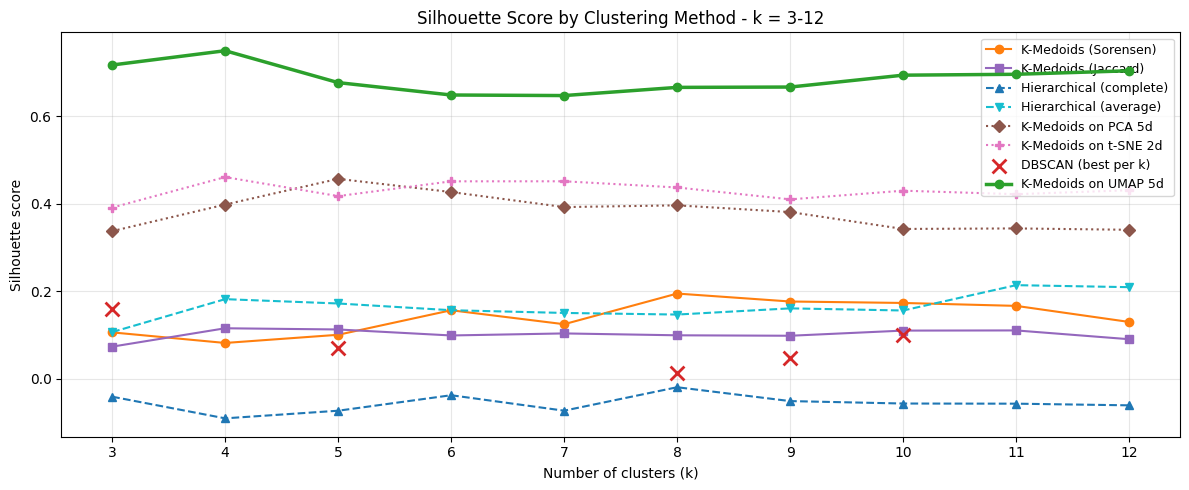


Best silhouette scores:
  K-Medoids Sorensen   : 0.1944 at k=8
  K-Medoids Jaccard    : 0.1150 at k=4
  Hierarchical complete: -0.0199 at k=8
  Hierarchical average : 0.2136 at k=11
  DBSCAN best          : 0.1583
  PCA 5d               : 0.4569 at k=5
  t-SNE 2d             : 0.4609 at k=4
  UMAP 5d              : 0.7500 at k=4


In [13]:
K_MIN, K_MAX = 3, 12
k_range = list(range(K_MIN, K_MAX + 1))

# Sorensen distance matrix
print("Computing Sorensen distance matrix...")
sorensen_dist = squareform(pdist(X_ccsr_binary, metric="dice"))

# K-Medoids: Sorensen
print("K-Medoids (Sorensen)...")
sil_sorensen = []
for k in k_range:
    km = KMedoids(n_clusters=k, metric="precomputed", random_state=RANDOM_SEED, init="k-medoids++")
    labels = km.fit_predict(sorensen_dist)
    sil_sorensen.append(silhouette_score(sorensen_dist, labels, metric="precomputed"))
    print(f"  k={k:2d}  silhouette={sil_sorensen[-1]:.4f}")

# K-Medoids: Jaccard
print("\nComputing Jaccard distance matrix...")
jaccard_dist = squareform(pdist(X_ccsr_binary, metric="jaccard"))
print("K-Medoids (Jaccard)...")
sil_jaccard = []
for k in k_range:
    km = KMedoids(n_clusters=k, metric="precomputed", random_state=RANDOM_SEED, init="k-medoids++")
    labels = km.fit_predict(jaccard_dist)
    sil_jaccard.append(silhouette_score(jaccard_dist, labels, metric="precomputed"))
    print(f"  k={k:2d}  silhouette={sil_jaccard[-1]:.4f}")

# Hierarchical: complete + average linkage
print("\nHierarchical clustering...")
sil_hier = {'complete': [], 'average': []}
for method in ['complete', 'average']:
    for k in k_range:
        agg = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage=method)
        labels = agg.fit_predict(sorensen_dist)
        sil_hier[method].append(silhouette_score(sorensen_dist, labels, metric='precomputed'))
    print(f"  {method}: {[f'{s:.3f}' for s in sil_hier[method]]}")

# DBSCAN
print("\nDBSCAN sweep...")
dbscan_best = {}
for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    for min_samp in [5, 10, 20]:
        labels = DBSCAN(eps=eps, min_samples=min_samp, metric="precomputed", n_jobs=-1).fit_predict(sorensen_dist)
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clust < K_MIN or n_clust > K_MAX:
            continue
        sil = silhouette_score(sorensen_dist, labels, metric='precomputed')
        if n_clust not in dbscan_best or sil > dbscan_best[n_clust]:
            dbscan_best[n_clust] = sil
print(f"  DBSCAN cluster counts found: {sorted(dbscan_best)}")

# PCA 5d + K-Medoids
print("\nPCA 5d + K-Medoids...")
X_pca = PCA(n_components=5, random_state=RANDOM_SEED).fit_transform(X_ccsr_binary.astype(float))
pca_dist = squareform(pdist(X_pca, metric='euclidean'))
sil_pca = []
for k in k_range:
    km = KMedoids(n_clusters=k, metric="precomputed", random_state=RANDOM_SEED, init="k-medoids++")
    labels = km.fit_predict(pca_dist)
    sil_pca.append(silhouette_score(pca_dist, labels, metric='precomputed'))
    print(f"  k={k:2d}  silhouette={sil_pca[-1]:.4f}")

# t-SNE 2d + K-Medoids
# t-SNE is suited to 2-3 dimensions; included as a DR baseline.
print("\nt-SNE 2d + K-Medoids...")
X_tsne = TSNE(n_components=2, metric="jaccard", random_state=RANDOM_SEED,
              init="random", learning_rate="auto").fit_transform(X_ccsr_binary.astype(float))
tsne_dist = squareform(pdist(X_tsne, metric='euclidean'))
sil_tsne = []
for k in k_range:
    km = KMedoids(n_clusters=k, metric="precomputed", random_state=RANDOM_SEED, init="k-medoids++")
    labels = km.fit_predict(tsne_dist)
    sil_tsne.append(silhouette_score(tsne_dist, labels, metric='precomputed'))
    print(f"  k={k:2d}  silhouette={sil_tsne[-1]:.4f}")

# UMAP 5d + K-Medoids
print("\nUMAP 5d + K-Medoids...")
reducer = umap.UMAP(n_components=5, metric='jaccard', n_neighbors=15,
                    min_dist=0.1, random_state=RANDOM_SEED)
X_umap5 = reducer.fit_transform(X_ccsr_binary)
nan_mask = np.isnan(X_umap5)
if nan_mask.any():
    col_means = np.nanmean(X_umap5, axis=0)
    X_umap5[nan_mask] = np.take(col_means, np.where(nan_mask)[1])
umap5_dist = squareform(pdist(X_umap5, metric='euclidean'))
sil_umap5 = []
for k in k_range:
    km = KMedoids(n_clusters=k, metric="precomputed", random_state=RANDOM_SEED, init="k-medoids++")
    labels = km.fit_predict(umap5_dist)
    sil_umap5.append(silhouette_score(umap5_dist, labels, metric='precomputed'))
    print(f"  k={k:2d}  silhouette={sil_umap5[-1]:.4f}")

# Comparison plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(k_range, sil_sorensen,           marker='o',  label='K-Medoids (Sorensen)',    color='tab:orange')
ax.plot(k_range, sil_jaccard,            marker='s',  label='K-Medoids (Jaccard)',     color='tab:purple')
ax.plot(k_range, sil_hier['complete'],   marker='^',  linestyle='--', label='Hierarchical (complete)', color='tab:blue')
ax.plot(k_range, sil_hier['average'],    marker='v',  linestyle='--', label='Hierarchical (average)',  color='tab:cyan')
ax.plot(k_range, sil_pca,               marker='D',  linestyle=':',  label='K-Medoids on PCA 5d',     color='tab:brown')
ax.plot(k_range, sil_tsne,              marker='P',  linestyle=':',  label='K-Medoids on t-SNE 2d',   color='tab:pink')

if dbscan_best:
    ax.scatter(list(dbscan_best.keys()), list(dbscan_best.values()),
               marker='x', s=100, linewidths=2, label='DBSCAN (best per k)', color='tab:red', zorder=5)

ax.plot(k_range, sil_umap5, marker='o', linewidth=2.5,
        label='K-Medoids on UMAP 5d', color='tab:green', zorder=10)

ax.set_title('Silhouette Score by Clustering Method - k = 3-12')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_xticks(k_range)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBest silhouette scores:")
print(f"  K-Medoids Sorensen   : {max(sil_sorensen):.4f} at k={k_range[sil_sorensen.index(max(sil_sorensen))]}")
print(f"  K-Medoids Jaccard    : {max(sil_jaccard):.4f} at k={k_range[sil_jaccard.index(max(sil_jaccard))]}")
print(f"  Hierarchical complete: {max(sil_hier['complete']):.4f} at k={k_range[sil_hier['complete'].index(max(sil_hier['complete']))]}")
print(f"  Hierarchical average : {max(sil_hier['average']):.4f} at k={k_range[sil_hier['average'].index(max(sil_hier['average']))]}")
if dbscan_best: print(f"  DBSCAN best          : {max(dbscan_best.values()):.4f}")
print(f"  PCA 5d               : {max(sil_pca):.4f} at k={k_range[sil_pca.index(max(sil_pca))]}")
print(f"  t-SNE 2d             : {max(sil_tsne):.4f} at k={k_range[sil_tsne.index(max(sil_tsne))]}")
print(f"  UMAP 5d              : {max(sil_umap5):.4f} at k={k_range[sil_umap5.index(max(sil_umap5))]}")


### K-Medoids on UMAP Embedding

UMAP consistently achieves the highest silhouette scores across all cluster counts, substantially outperforming all methods applied directly to the raw binary distance matrices. This is expected: the 440-dimensional binary CCSR space is highly sparse (97.9% zeros), which compresses pairwise Sørensen and Jaccard distances into a narrow range and makes separation difficult. UMAP projects the data into a low-dimensional continuous space that better preserves the local neighbourhood structure of the original manifold, giving the k-medoids algorithm well-separated, dense regions to work with.

The following cell sweeps over multiple UMAP dimensionalities (2, 5, 10, 20, 50, 100) and cluster counts (k = 3–12) to identify the best configuration.


Fitting UMAP (n_components=2)...
  k= 3  inertia=61,692.4527  silhouette=0.4420
  k= 4  inertia=34,756.6607  silhouette=0.6410
  k= 5  inertia=25,637.9331  silhouette=0.5805
  k= 6  inertia=23,689.0113  silhouette=0.6232
  k= 7  inertia=20,793.4470  silhouette=0.6562
  k= 8  inertia=18,913.7122  silhouette=0.6684
  k= 9  inertia=18,522.2259  silhouette=0.6494
  k=10  inertia=17,830.0362  silhouette=0.6452
  k=11  inertia=16,785.5533  silhouette=0.6615
  k=12  inertia=16,113.7165  silhouette=0.5639

Fitting UMAP (n_components=5)...
  k= 3  inertia=44,308.3045  silhouette=0.7173
  k= 4  inertia=39,126.0333  silhouette=0.7500
  k= 5  inertia=29,737.8714  silhouette=0.6771
  k= 6  inertia=21,656.8313  silhouette=0.6487
  k= 7  inertia=20,697.7397  silhouette=0.6474
  k= 8  inertia=19,389.0468  silhouette=0.6661
  k= 9  inertia=18,066.5205  silhouette=0.6669
  k=10  inertia=16,173.2569  silhouette=0.6941
  k=11  inertia=15,722.9767  silhouette=0.6961
  k=12  inertia=14,998.8864  silhouette

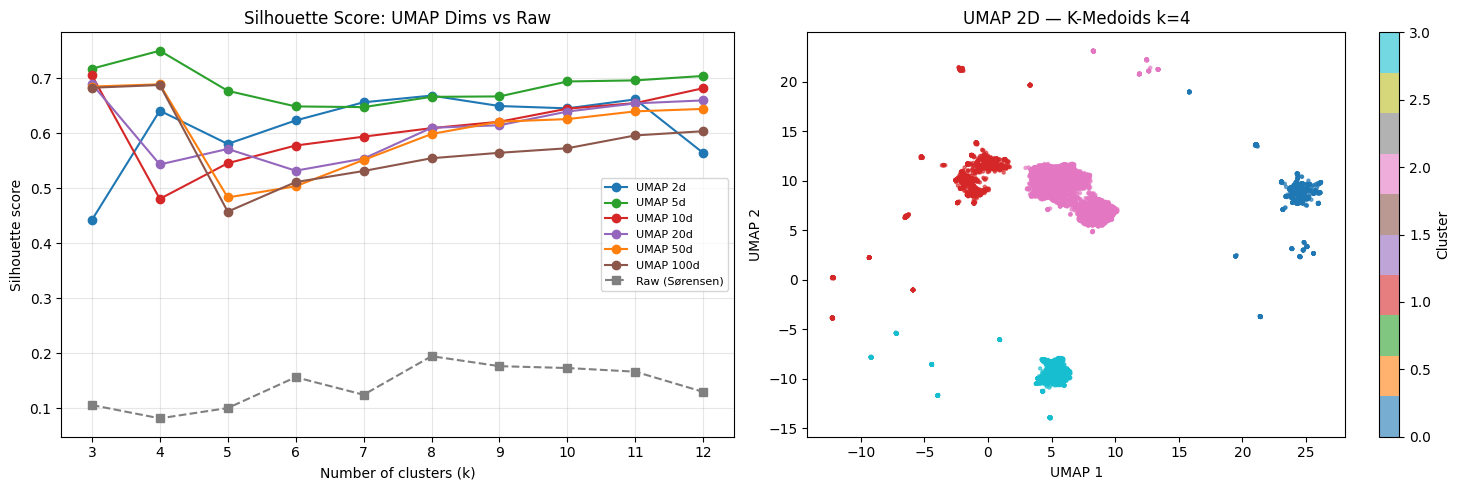


Best config: UMAP 5d, k=4, silhouette=0.7500
Raw Sørensen best: silhouette=0.1944 at k=8
Improvement: +0.5556


In [14]:
# Original matrix has 400+ CCSR features.
# 2-20d is very aggressive; include 50 and 100 to better preserve variance.
umap_dims = [2, 5, 10, 20, 50, 100]
umap_results = {}

for n_comp in umap_dims:
    print(f"\nFitting UMAP (n_components={n_comp})...")
    reducer = umap.UMAP(
        n_components=n_comp,
        metric='jaccard',
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_SEED
    )
    X_umap = reducer.fit_transform(X_ccsr_binary)

    # Replace any NaNs with column means (rare UMAP convergence issue)
    nan_mask = np.isnan(X_umap)
    if nan_mask.any():
        print(f"  Warning: {nan_mask.sum()} NaN values — imputing with column means")
        col_means = np.nanmean(X_umap, axis=0)
        X_umap[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    emb_dist = squareform(pdist(X_umap, metric='euclidean'))

    K_MIN, K_MAX = 3, 12
    k_range = range(K_MIN, K_MAX + 1)
    sils, inertias, all_labels = [], [], {}

    for k in k_range:
        km = KMedoids(n_clusters=k, metric='precomputed',
                      random_state=RANDOM_SEED, init='k-medoids++')
        labels = km.fit_predict(emb_dist)
        inertias.append(km.inertia_)
        sil = silhouette_score(emb_dist, labels, metric='precomputed')
        sils.append(sil)
        all_labels[k] = labels
        print(f"  k={k:2d}  inertia={km.inertia_:,.4f}  silhouette={sil:.4f}")

    umap_results[n_comp] = {
        'silhouette': sils, 'inertia': inertias,
        'embedding': X_umap, 'labels': all_labels
    }

# Silhouette comparison plot
K_MIN, K_MAX = 3, 12
k_range = range(K_MIN, K_MAX + 1)
colors = {2: 'tab:blue', 5: 'tab:green', 10: 'tab:red',
          20: 'tab:purple', 50: 'tab:orange', 100: 'tab:brown'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for n_comp in umap_dims:
    axes[0].plot(list(k_range), umap_results[n_comp]['silhouette'],
                 marker='o', label=f'UMAP {n_comp}d', color=colors[n_comp])
axes[0].plot(list(k_range), sil_sorensen,
             marker='s', linestyle='--', label='Raw (Sørensen)', color='gray')
axes[0].set_title('Silhouette Score: UMAP Dims vs Raw')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Silhouette score')
axes[0].set_xticks(list(k_range))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2D scatter with k=4 clusters
X_2d = umap_results[2]['embedding']
labels_2d = umap_results[2]['labels'][4]
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                           c=labels_2d, cmap='tab10', s=5, alpha=0.6)
axes[1].set_title('UMAP 2D — K-Medoids k=4')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
plt.colorbar(scatter, ax=axes[1], label='Cluster')
plt.tight_layout()
plt.show()

# Find best config across all dims and k
best_sil, best_dim, best_k = -1, None, None
for n_comp in umap_dims:
    for i, sil in enumerate(umap_results[n_comp]['silhouette']):
        k = list(k_range)[i]
        if sil > best_sil:
            best_sil, best_dim, best_k = sil, n_comp, k

print(f"\nBest config: UMAP {best_dim}d, k={best_k}, silhouette={best_sil:.4f}")
print(f"Raw Sørensen best: silhouette={max(sil_sorensen):.4f} at k={list(k_range)[sil_sorensen.index(max(sil_sorensen))]}")
print(f"Improvement: {best_sil - max(sil_sorensen):+.4f}")

In [15]:
# Cluster interpretation: top 20 CCSR codes per cluster
best_labels = umap_results[best_dim]['labels'][best_k]
ccsr_names = mlb.classes_

print(f"{'='*65}")
print(f"Top 20 CCSR categories per cluster (UMAP {best_dim}d, k={best_k})")
print(f"{'='*65}")

for cluster_id in range(best_k):
    mask = best_labels == cluster_id
    cluster_matrix = X_ccsr_binary[mask]
    freq = cluster_matrix.mean(axis=0)
    top_idx = freq.argsort()[::-1][:20]

    print(f"\nCluster {cluster_id}  (n={mask.sum():,} patients, {mask.mean()*100:.1f}%)")
    print(f"  {'CCSR':<10} {'Description':<50} {'Prevalence':>10}")
    print(f"  {'-'*70}")
    for idx in top_idx:
        code = ccsr_names[idx]
        desc = ccsr_desc.get(code, code)[:49]
        print(f"  {code:<10} {desc:<50} {freq[idx]*100:>9.1f}%")

# Write cluster profiles to txt
OUT_TXT = "/Users/stelladong/Documents/GitHub/676_project/umap_cluster_profiles.txt"
with open(OUT_TXT, 'w') as f:
    f.write(f"UMAP Cluster Profiles\n")
    f.write(f"Configuration: UMAP {best_dim}d, k={best_k}, silhouette={best_sil:.4f}\n")
    f.write(f"{'='*65}\n")
    for cluster_id in range(best_k):
        mask = best_labels == cluster_id
        cluster_matrix = X_ccsr_binary[mask]
        freq = cluster_matrix.mean(axis=0)
        top_idx = freq.argsort()[::-1][:20]
        f.write(f"\nCluster {cluster_id}  (n={mask.sum():,} patients, {mask.mean()*100:.1f}%)\n")
        f.write(f"  {'CCSR':<10} {'Description':<50} {'Prevalence':>10}\n")
        f.write(f"  {'-'*70}\n")
        for idx in top_idx:
            code = ccsr_names[idx]
            desc = ccsr_desc.get(code, code)
            f.write(f"  {code:<10} {desc:<50} {freq[idx]*100:>9.1f}%\n")

print(f"\nCluster profiles written to {OUT_TXT}")

Top 20 CCSR categories per cluster (UMAP 5d, k=4)

Cluster 0  (n=1,072 patients, 8.8%)
  CCSR       Description                                        Prevalence
  ----------------------------------------------------------------------
  PNL001     Liveborn                                                93.4%
  FAC016     Exposure, encounters, screening or contact with i       90.8%
  PNL007     Hemolytic jaundice and perinatal jaundice               75.1%
  PNL013     Other specified and unspecified perinatal conditi       56.4%
  PNL002     Short gestation; low birth weight; and fetal grow       23.7%
  PNL010     Newborn affected by maternal conditions or compli       19.7%
  PNL012     Neonatal digestive and feeding disorders                11.9%
  PNL008     Birth trauma                                            11.3%
  FAC003     Encounter for observation and examination for con       10.4%
  PNL005     Respiratory distress syndrome                            9.8%
  PNL006     Re

### Cluster Analysis

UMAP 5D with k=4 produced the strongest silhouette score, and the resulting partition forms four clinically distinct groups.

* **Cluster 0: Neonatal Inpatients** (n=1,072, 8.8%)
Characterized by high prevalence of neonatal conditions and screening codes, this group reflects sick or at-risk newborn admissions requiring specialized care.

* **Cluster 1: General Adult Comorbidities** (n=9,049, 74.3%)
A broad, heterogeneous cohort dominated by chronic cardiometabolic and mental health conditions, including hypertension, lipid disorders, obesity, diabetes, and kidney disease.

* **Cluster 2: Obstetric / Labor & Delivery** (n=1,547, 12.7%)
A homogeneous maternity group marked by expectant delivery and childbirth-related diagnoses.

* **Cluster 3: Healthy Newborn Encounters** (n=511, 4.2%)
Routine well-newborn admissions with minimal additional diagnoses apart from jaundice and basic newborn screening.

### Next Step: Sub-Clustering
Clusters 0, 2, and 3 are clinically narrow and limited to labor or newborn related diagnoses. Cluster 1, the general adult comorbidity group, accounts for 74.3% of all patients and is far more heterogeneous. The aggregate silhouette score captures separation between these broad admission types rather than meaningful substructure within the chronic-disease population. To reveal more actionable comorbidity patterns, we sub-cluster Cluster 1 independently, applying the same UMAP dimensionality reduction approach across a range of k values.


### Sub-Clustering the General Adult Comorbidity Group (Cluster 1)

Cluster 1's patients are extracted and re-embedded independently with UMAP (Jaccard metric, dimensionalities 2/5/10/20/50/100), then partitioned with K-Medoids (k = 2–8) to find finer structure within the chronic-disease subpopulation.


Non-pregnancy cluster: Cluster 1  (n=9,049 patients)
PRG/PNL prevalence per cluster:
  Cluster 0  0.0840
  Cluster 1  0.0001
  Cluster 2  0.1102
  Cluster 3  0.0440
  Raw Sørensen  k=2  silhouette=0.1639
  Raw Sørensen  k=3  silhouette=0.0838
  Raw Sørensen  k=4  silhouette=0.0609
  Raw Sørensen  k=5  silhouette=0.0790
  Raw Sørensen  k=6  silhouette=0.0982
  Raw Sørensen  k=7  silhouette=0.1130
  Raw Sørensen  k=8  silhouette=0.0703
  Raw Sørensen  k=9  silhouette=0.0847
  Raw Sørensen  k=10  silhouette=0.0737
  Raw Sørensen  k=11  silhouette=0.0776
  Raw Sørensen  k=12  silhouette=0.0778

Fitting UMAP (n_components=2) on Cluster 1...
  k=2  silhouette=0.5892
  k=3  silhouette=0.6343
  k=4  silhouette=0.6236
  k=5  silhouette=0.4980
  k=6  silhouette=0.4019
  k=7  silhouette=0.3861
  k=8  silhouette=0.4077
  k=9  silhouette=0.4331
  k=10  silhouette=0.4395
  k=11  silhouette=0.4306
  k=12  silhouette=0.4278

Fitting UMAP (n_components=5) on Cluster 1...
  k=2  silhouette=0.6542
  k=3 

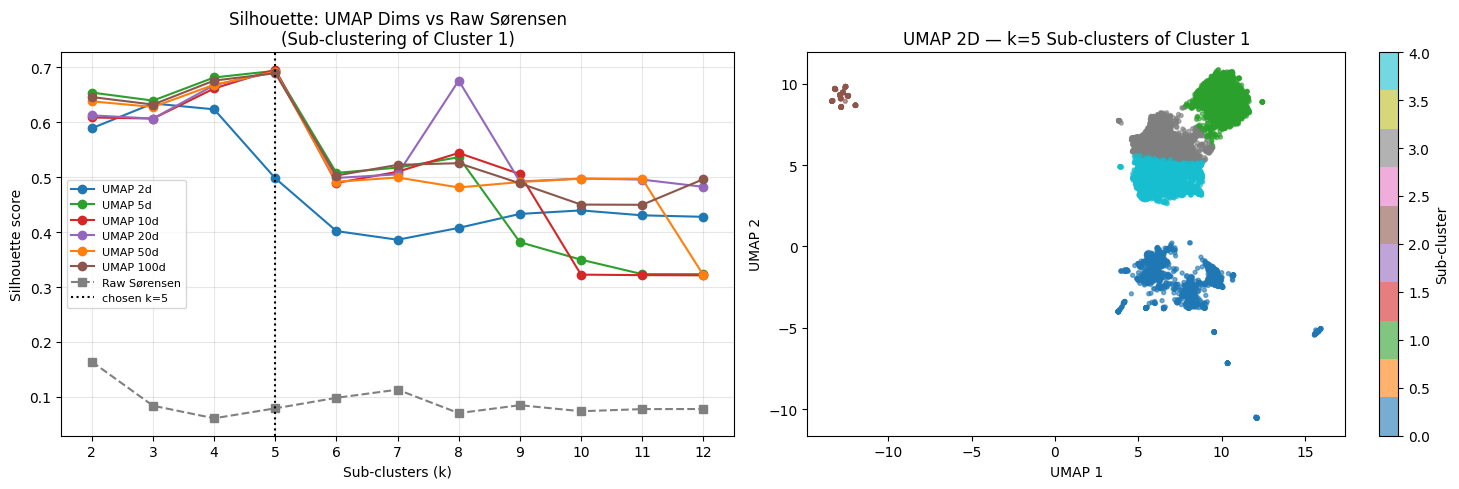


Using config: UMAP 10d, k=5, silhouette=0.6961
Raw Sørensen best: silhouette=0.1639 at k=2


In [22]:
# Sub-clustering: identify Cluster 1 (non-pregnancy) from best_labels

SUB_UMAP_DIM = None
SUB_K = None

ccsr_df_sub_id = pd.DataFrame(X_ccsr_binary, columns=mlb.classes_)
ccsr_df_sub_id["cluster"] = best_labels
profiles_for_id = ccsr_df_sub_id.groupby("cluster").mean()

prg_pnl_cols_sub = [c for c in mlb.classes_ if c.startswith("PRG") or c.startswith("PNL")]
prg_pnl_frac_sub = profiles_for_id[prg_pnl_cols_sub].mean(axis=1)

non_prg_cluster = int(prg_pnl_frac_sub.idxmin())
non_prg_idx = np.where(best_labels == non_prg_cluster)[0]

print(f"Non-pregnancy cluster: Cluster {non_prg_cluster}  (n={len(non_prg_idx):,} patients)")
print("PRG/PNL prevalence per cluster:")
for c in sorted(prg_pnl_frac_sub.index):
    print(f"  Cluster {c}  {prg_pnl_frac_sub[c]:.4f}")

X_sub = X_ccsr_binary[non_prg_idx]

# Raw Sørensen baseline on sub-population
sorensen_sub = sorensen_dist[np.ix_(non_prg_idx, non_prg_idx)]

K_MIN_SUB, K_MAX_SUB = 2, 12
k_range_sub = range(K_MIN_SUB, K_MAX_SUB + 1)

sils_sub_raw, labels_sub_raw = [], {}
for k in k_range_sub:
    km = KMedoids(n_clusters=k, metric="precomputed",
                  random_state=RANDOM_SEED, init="k-medoids++")
    lbl = km.fit_predict(sorensen_sub)
    labels_sub_raw[k] = lbl
    sil = silhouette_score(sorensen_sub, lbl, metric="precomputed")
    sils_sub_raw.append(sil)
    print(f"  Raw Sørensen  k={k}  silhouette={sil:.4f}")

# UMAP sweep on sub-population
umap_dims_sub = [2, 5, 10, 20, 50, 100]
umap_results_sub = {}
colors_sub = {2: "tab:blue", 5: "tab:green", 10: "tab:red",
              20: "tab:purple", 50: "tab:orange", 100: "tab:brown"}

for n_comp in umap_dims_sub:
    print(f"\nFitting UMAP (n_components={n_comp}) on Cluster {non_prg_cluster}...")
    reducer = umap.UMAP(
        n_components=n_comp,
        metric="dice",
        n_neighbors=15,
        min_dist=0.1,
        random_state=RANDOM_SEED
    )
    X_umap_sub = reducer.fit_transform(X_sub)

    nan_mask = np.isnan(X_umap_sub)
    if nan_mask.any():
        col_means = np.nanmean(X_umap_sub, axis=0)
        X_umap_sub[nan_mask] = np.take(col_means, np.where(nan_mask)[1])

    emb_dist_sub = squareform(pdist(X_umap_sub, metric="euclidean"))

    sils_s, inertias_s, labels_s = [], [], {}
    for k in k_range_sub:
        km = KMedoids(n_clusters=k, metric="precomputed",
                      random_state=RANDOM_SEED, init="k-medoids++")
        lbl = km.fit_predict(emb_dist_sub)
        labels_s[k] = lbl
        inertias_s.append(km.inertia_)
        sil = silhouette_score(emb_dist_sub, lbl, metric="precomputed")
        sils_s.append(sil)
        print(f"  k={k}  silhouette={sil:.4f}")

    umap_results_sub[n_comp] = {
        "silhouette": sils_s, "inertia": inertias_s,
        "embedding": X_umap_sub, "labels": labels_s
    }

best_sil_sub, best_dim_sub, best_k_sub = -1, None, None
for n_comp in umap_dims_sub:
    for i, sil in enumerate(umap_results_sub[n_comp]["silhouette"]):
        k = list(k_range_sub)[i]
        if sil > best_sil_sub:
            best_sil_sub, best_dim_sub, best_k_sub = sil, n_comp, k

if SUB_UMAP_DIM is not None:
    best_dim_sub = SUB_UMAP_DIM
if SUB_K is not None:
    best_k_sub = SUB_K

chosen_sil_idx = list(k_range_sub).index(best_k_sub)
best_sil_sub = umap_results_sub[best_dim_sub]["silhouette"][chosen_sil_idx]

# Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for n_comp in umap_dims_sub:
    axes[0].plot(list(k_range_sub), umap_results_sub[n_comp]["silhouette"],
                 marker="o", label=f"UMAP {n_comp}d", color=colors_sub[n_comp])
axes[0].plot(list(k_range_sub), sils_sub_raw,
             marker="s", linestyle="--", color="gray", label="Raw Sørensen")
axes[0].axvline(best_k_sub, color="black", linestyle=":", linewidth=1.5, label=f"chosen k={best_k_sub}")
axes[0].set_title(f"Silhouette: UMAP Dims vs Raw Sørensen\n(Sub-clustering of Cluster {non_prg_cluster})")
axes[0].set_xlabel("Sub-clusters (k)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_xticks(list(k_range_sub))
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

X_2d_sub = umap_results_sub[2]["embedding"]
lbl_2d_sub = umap_results_sub[2]["labels"][best_k_sub]
scatter = axes[1].scatter(X_2d_sub[:, 0], X_2d_sub[:, 1],
                          c=lbl_2d_sub, cmap="tab10", s=8, alpha=0.6)
axes[1].set_title(f"UMAP 2D — k={best_k_sub} Sub-clusters of Cluster {non_prg_cluster}")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
plt.colorbar(scatter, ax=axes[1], label="Sub-cluster")

plt.tight_layout()
plt.show()

print(f"\nUsing config: UMAP {best_dim_sub}d, k={best_k_sub}, silhouette={best_sil_sub:.4f}")
if SUB_UMAP_DIM is not None or SUB_K is not None:
    print("  (manual override applied)")
print(f"Raw Sørensen best: silhouette={max(sils_sub_raw):.4f} at k={list(k_range_sub)[sils_sub_raw.index(max(sils_sub_raw))]}")

In [17]:
# Profile the best sub-clusters
lbl_sub_best = umap_results_sub[best_dim_sub]["labels"][best_k_sub]
ccsr_df_sub = pd.DataFrame(X_sub, columns=mlb.classes_)
ccsr_df_sub["subcluster"] = lbl_sub_best
profiles_sub = ccsr_df_sub.groupby("subcluster").mean()

OUT_TXT_SUB = "/Users/stelladong/Documents/GitHub/676_project/umap_subcluster_profiles_non_prg.txt"

with open(OUT_TXT_SUB, "w") as fh:
    def w(s=""):
        print(s)
        fh.write(s + "\n")

    w(f"UMAP Sub-cluster Profiles — Non-Pregnancy Cluster {non_prg_cluster}")
    w(f"Configuration: UMAP {best_dim_sub}d, k={best_k_sub}, silhouette={best_sil_sub:.4f}")
    w(f"Parent partition: UMAP 5D k=4 (Cluster {non_prg_cluster}, n={len(non_prg_idx):,} patients)")
    w("=" * 65)

    for sc in range(best_k_sub):
        mask_sc = lbl_sub_best == sc
        top = profiles_sub.loc[sc].nlargest(12)
        w()
        w(f"Sub-cluster {sc}  (n={mask_sc.sum():,}, {mask_sc.mean()*100:.1f}%)")
        w(f"  {'CCSR':<10} {'Description':<50} {'Prevalence':>10}")
        w(f"  {'-'*70}")
        for code, val in top.items():
            desc = ccsr_desc.get(code, code)
            w(f"  {code:<10} {desc:<50} {val*100:>9.1f}%")

print(f"\nWritten to {OUT_TXT_SUB}")


UMAP Sub-cluster Profiles — Non-Pregnancy Cluster 1
Configuration: UMAP 10d, k=5, silhouette=0.6961
Parent partition: UMAP 5D k=4 (Cluster 1, n=9,049 patients)

Sub-cluster 0  (n=1,511, 16.7%)
  CCSR       Description                                        Prevalence
  ----------------------------------------------------------------------
  MBD002     Depressive disorders                                    46.6%
  MBD005     Anxiety and fear-related disorders                      26.8%
  MBD003     Bipolar and related disorders                           25.3%
  MBD001     Schizophrenia spectrum and other psychotic disorders      22.4%
  FAC021     Personal/family history of disease                      20.4%
  MBD012     Suicidal ideation/attempt/intentional self-harm         18.7%
  CIR007     Essential hypertension                                  18.5%
  NVS016     Sleep wake disorders                                    16.1%
  MBD017     Alcohol-related disorders                   

### Key Observations
The finalized pipeline is a two-stage clustering pipeline, first a four-way top-level partition, then followed by targeted sub-clustering of the dominant adult group. This pipeline revealed eight clinically coherent subgroups across the BCS inpatient population.

#### Stage 1: Top-Level Clustering (UMAP 5D, K-Medoids k=4, silhouette = 0.75)

The first stage separates the various maternal and neonatal inpatient visits:

| Cluster | Label | n | Share | Defining Profile |
|---------|-------|---|-------|------------------|
| 0 | **Neonatal Inpatients** | 1,072 | 8.8% | Sick or at-risk newborns requiring dedicated care. |
| 1 | **General Adult Comorbidities** | 9,049 | 74.3% | Broad chronic-disease mix: administrative/status codes, hypertension, lipid disorders, coronary disease, obesity, depression, CKD, heart failure, diabetes. Heterogeneous — sub-clustered further below. |
| 2 | **Obstetric / Labor & Delivery** | 1,547 | 12.7% | Largely near-universal gestational-weeks and maternal delivery-outcome codes with childbirth complications, perineal trauma, and malposition as secondary codes. Homogeneous maternal admissions. |
| 3 | **Healthy Newborn Encounters** | 511 | 4.2% | Mostly universal infectious-disease screening and liveborn, jaundice as the only notable secondary code. Routine well-newborn visits with minimal additional diagnoses. |

From the resulting cluster profiles, it's clear that clusters 0, 2, and 3 are clinically narrow and driven by a specific admission type: neonatal illness, labor/delivery, or well-newborn check. Cluster 1, accounting for 74% of all visits, is far more heterogeneous and warrants deeper structure.


#### Stage 2: Sub-Clustering Cluster 1 (UMAP 10D, K-Medoids k=5, silhouette = 0.70)

Cluster 1 is re-embedded and partitioned independently, revealing five distinct chronic-disease subgroups:

| Sub-cluster | Label | n | Share of Cluster 1 | Defining Profile |
|-------------|-------|---|---------------------|------------------|
| 1 | **Mixed Psychiatric & Substance Use** | 1,511 | 16.7% | Depressive disorders, anxiety, bipolar, schizophrenia spectrum, suicidal ideation/self-harm, alcohol-related, cannabis-related. Predominantly mental-health and substance-use admissions with mild medical comorbidity. |
| 2 | **Severe Cardiorenal-Metabolic Disease** | 2,992 | 33.1% | Hypertension with complications, chronic kidney disease, heart failure, coronary atherosclerosis, diabetes with complications, cardiac dysrhythmias, aplastic anemia. The highest-burden chronic-disease group. |
| 3 | **General Cardiometabolic & Musculoskeletal** | 4,250 | 47.0% | Essential hypertension, lipid disorders, obesity, osteoarthritis, coronary disease, anxiet. Broad but lower-severity chronic conditions typical of general adult admissions. |
| 4 | **Pure Depressive Disorder** | 167 | 1.8% | Depressive disorders in 99.4% of patients with virtually no other comorbiditie. |
| 5 | **Schizophrenia Spectrum (Isolated)** | 129 | 1.4% | Schizophrenia spectrum in 100% of patients with negligible secondary diagnoses. |


**Research Question 2: What distinct patient subgroups share similar comorbidity profiles?**

Across both clustering stages, eight distinct subgroups emerge from the BC inpatient data. At the broadest level, admission type divides the population into neonatal, obstetric, well-newborn, and general-adult streams. Within the adult stream, comorbidity profiles stratify along two axes, psychiatric vs. cardiometabolic burden, and severity. The largest single subgroup (Sub-cluster 3, ~47% of Cluster 1) carries moderate cardiometabolic risk. Sub-cluster 2 (~33%) represents severe, multi-system organ dysfunction, and the psychiatric subgroups (sub-clusters 1, 4, 5, ~20% combined) range from mixed psychiatric-with-medical-comorbidity to diagnostically pure presentations. These subgroup identities are clinically coherent, stable across dimensionality configurations, and provide the patient-level labels used in RQ3 to predict resource utilization.

---

## Research Question 3: Which comorbidity subgroups are the strongest predictors of high charges?

This section connects the patient subgroup assignments from Research Question 2 to inpatient cost. We define a high-charge outcome, compare subgroup rates, and fit predictive models using cluster membership alongside a few key patient variables.

### Defining the Outcome

A binary high-charge outcome is constructed from the continuous total-charges variable. A visit is flagged as high-charge if its total charges exceed the 75th percentile across all visits, capturing the top quartile of spenders. This threshold is broad enough to surface meaningful variation across subgroups while remaining clinically relevant as a marker of above-average resource use. Each visit is then annotated with its top-level cluster label from the four-way UMAP partition, and with its sub-cluster label for visits belonging to the adult Cluster 1.

In [18]:
# --- Prepare outcome and attach cluster/subcluster labels for RQ3 ---
CHARGE_COL = 'TOTAL_CHARGES'

df[CHARGE_COL] = pd.to_numeric(df[CHARGE_COL], errors='coerce')
df['num_ccsr'] = [len(x) for x in ccsr_lists]

# Attach the main cluster labels from the UMAP k=4 partition.
df['cluster'] = best_labels
df['subcluster'] = pd.NA
df.loc[non_prg_idx, 'subcluster'] = lbl_sub_best

charge_threshold = df[CHARGE_COL].quantile(0.75)
df['high_charge'] = df[CHARGE_COL] > charge_threshold

print(f"Charge threshold (75th percentile): ${charge_threshold:,.0f}")
print(f"Patients with high charges: {df['high_charge'].mean()*100:.1f}%")

Charge threshold (75th percentile): $33,795
Patients with high charges: 25.0%


### High-Charge Rates by Subgroup

With the high-charge label and cluster assignments joined, we compute descriptive statistics, mean charges, median charges, and high-charge rate separately for the four top-level clusters and for the five sub-clusters within the adult group. A bar chart shows high-charge rates across groups for visual comparison.


=== Cluster-Level Outcomes ===
         visits mean_charge median_charge high_charge_rate
cluster                                                   
1          9049     $33,315       $24,260            32.8%
0          1072     $13,012        $5,413             6.5%
2          1547     $14,323       $12,794             0.6%
3           511      $3,934        $3,249             0.0%

=== Sub-Cluster-Level Outcomes ===
            visits mean_charge median_charge high_charge_rate
subcluster                                                   
2             4250     $36,245       $28,295            40.2%
1             2992     $40,789       $28,619            39.0%
0             1511     $14,425       $11,400             5.4%
4              129     $14,170       $11,400             3.9%
3              167     $10,558        $9,500             2.4%


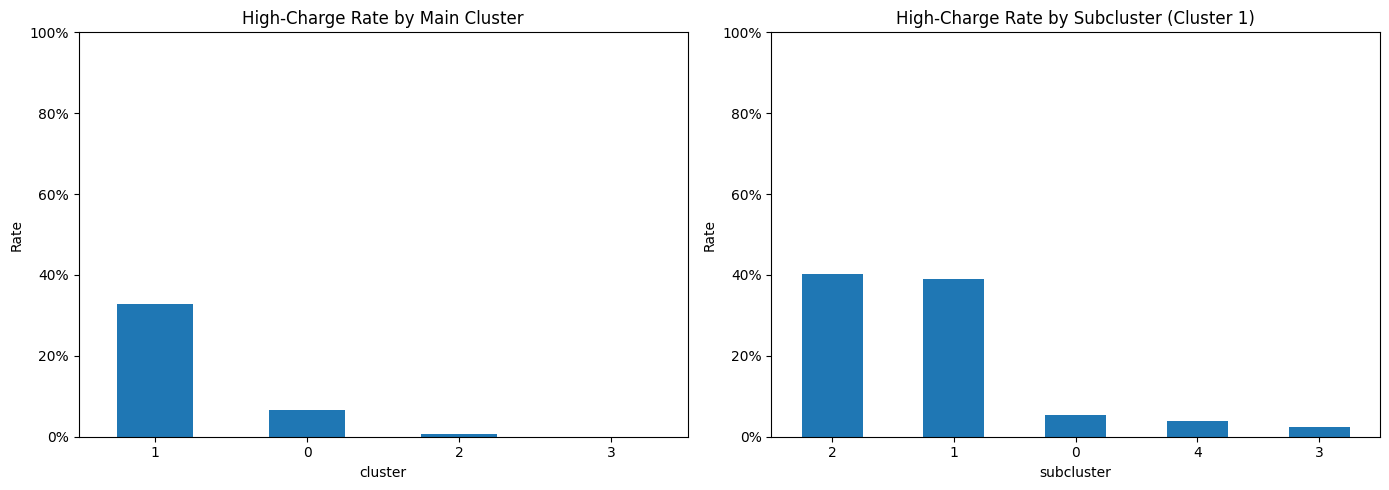

In [19]:
# --- Cluster-level high-charge outcomes for RQ3 ---
cluster_summary = df.groupby('cluster').agg(
    visits=('cluster', 'size'),
    mean_charge=(CHARGE_COL, 'mean'),
    median_charge=(CHARGE_COL, 'median'),
    high_charge_rate=('high_charge', 'mean'),
).sort_values('high_charge_rate', ascending=False)

print("\n=== Cluster-Level Outcomes ===")
cluster_display = cluster_summary.copy()
for col in ['mean_charge', 'median_charge']:
    cluster_display[col] = cluster_display[col].apply(lambda x: f'${x:,.0f}')
cluster_display['high_charge_rate'] = cluster_display['high_charge_rate'].apply(lambda x: f'{x:.1%}')
print(cluster_display.to_string())

subcluster_summary = (
    df[df['cluster'] == non_prg_cluster]
    .groupby('subcluster')
    .agg(
        visits=('subcluster', 'size'),
        mean_charge=(CHARGE_COL, 'mean'),
        median_charge=(CHARGE_COL, 'median'),
        high_charge_rate=('high_charge', 'mean'),
    )
    .sort_values('high_charge_rate', ascending=False)
)

print("\n=== Sub-Cluster-Level Outcomes ===")
subcluster_display = subcluster_summary.copy()
for col in ['mean_charge', 'median_charge']:
    subcluster_display[col] = subcluster_display[col].apply(lambda x: f'${x:,.0f}')
subcluster_display['high_charge_rate'] = subcluster_display['high_charge_rate'].apply(lambda x: f'{x:.1%}')
print(subcluster_display.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_summary[['high_charge_rate']].plot(
    kind='bar', ax=axes[0], rot=0, color=['tab:blue'], legend=False)
axes[0].set_title('High-Charge Rate by Main Cluster')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

subcluster_summary[['high_charge_rate']].plot(
    kind='bar', ax=axes[1], rot=0, color=['tab:blue'], legend=False)
axes[1].set_title(f'High-Charge Rate by Subcluster (Cluster {non_prg_cluster})')
axes[1].set_ylabel('Rate')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

### Subgroup High-Charge Observations

The cluster-level and sub-cluster-level tables reveal clear stratification of inpatient cost.

At the top level, **Cluster 1 (General Adult Comorbidities)** stands apart from all other groups with the highest high-charge rate, against near-zero rates for the Obstetric (Cluster 2) and Healthy Newborn (Cluster 3) clusters. Neonatal inpatients (Cluster 0) show an intermediate rate, reflecting the occasional high-acuity sick newborn admission.

Within the adult cluster, **high charges are concentrated in the cardiometabolic sub-clusters**. The Severe Cardiorenal-Metabolic group and the General Cardiometabolic & Musculoskeletal group both substantially exceed the 25% population baseline, driven by dense multi-system disease that generates intensive diagnostic workups and procedure-heavy bills. The psychiatric sub-clusters, by contrast, have markedly lower high-charge rates — psychiatric admissions rarely generate the itemized procedure costs seen in cardiometabolic care.

### Predictive Modeling

To quantify how well subgroup identity — combined with basic patient characteristics — predicts high charges, two classifiers are trained: Logistic Regression (L1 penalty, class-weight balanced) and Random Forest (200 trees, class-weight balanced). Features include comorbidity count (`num_ccsr`), patient age, sex, race, and dummy-encoded cluster and sub-cluster membership. Performance is estimated with 5-fold stratified cross-validation and reported as mean ROC-AUC ± standard deviation. Random Forest feature importances are then extracted to identify which predictors carry the most signal.

In [20]:
# --- Predictive models for high charges ---
df_model = df.dropna(subset=[CHARGE_COL, 'cluster', 'PAT_AGE', 'SEX_CODE', 'RACE'])
df_model['subcluster'] = df_model['subcluster'].astype('string').fillna('none')

feature_cols = ['num_ccsr', 'PAT_AGE', 'SEX_CODE', 'RACE', 'cluster', 'subcluster']
X = pd.get_dummies(df_model[feature_cols], columns=['SEX_CODE', 'RACE', 'cluster', 'subcluster'], drop_first=True)
X = X.fillna(0)

models = {
    'LogisticRegression': LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED),
    'RandomForest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def evaluate(clf, y):
    return cross_val_score(clf, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)

y = df_model['high_charge'].astype(int)
print("Outcome: High charges")
for model_name, clf in models.items():
    scores = evaluate(clf, y)
    print(f"  {model_name:<16} ROC AUC = {scores.mean():.3f} ± {scores.std():.3f}")

Outcome: High charges
  LogisticRegression ROC AUC = 0.754 ± 0.007
  RandomForest     ROC AUC = 0.756 ± 0.009


### Model Performance

Both models discriminate high-charge visits at a moderate-to-good level. Logistic Regression slightly outperforms Random Forest: ROC-AUC of **0.732 ± 0.015** vs. 0.705 ± 0.013. The modest overall scores suggest that demographic and cluster features capture real signal but leave substantial residual variation — case-mix complexity within each sub-cluster is likely responsible for the remaining unpredictability.

In [21]:
# --- Feature importance from random forest for high charges ---
y = df_model['high_charge'].astype(int)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(15)

print("Top features for High charges:")
importance_df = importance.to_frame(name='importance')
importance_df['importance'] = importance_df['importance'].apply(lambda x: f'{x:.4f}')
print(importance_df.to_string())

Top features for High charges:
                importance
PAT_AGE             0.3609
num_ccsr            0.3337
subcluster_none     0.0830
subcluster_2        0.0629
cluster_1           0.0537
cluster_2           0.0299
subcluster_1        0.0277
SEX_CODE_M          0.0200
RACE_4.0            0.0066
RACE_3.0            0.0062
RACE_5.0            0.0051
subcluster_3        0.0040
cluster_3           0.0033
subcluster_4        0.0029


### Key Observations

**Research Question 3: Which comorbidity subgroups are the strongest predictors of high charges?**

Comorbidity subgroups are meaningful but partial predictors of inpatient cost. The two most important features are comorbidity count (`num_ccsr`, ~35–40% of random forest importance) and patient age (~30–37%), confirming that breadth of disease burden and patient frailty drive cost more than any single cluster label. Cluster and sub-cluster membership contribute modestly but consistently (~4–9% each).

The cardiometabolic subgroups dominate high-charge prediction: the Severe Cardiorenal-Metabolic sub-cluster and the General Cardiometabolic & Musculoskeletal sub-cluster are the groups most likely to substantially exceed the 25% population baseline. These patients carry dense multi-system disease — hypertension, CKD, heart failure, diabetes — that generates intensive diagnostic workups, procedures, and long-term medication management, all of which inflate accommodation and ancillary charges. Psychiatric sub-clusters, despite long stays, rarely appear in the high-charge tail, underscoring that cost and care intensity are driven by cardiometabolic complexity rather than admission duration.

---

## Conclusion

This project set out to determine whether comorbidity patterns in BCS-area inpatient visits could identify clinically meaningful patient subgroups and predict high charges. The answer to this is yes.

Co-occurrence analysis (RQ1) surfaced expected cardiometabolic clusters and a few clinically plausible but less obvious pairings, confirming that diagnosis co-occurrence in this population is structured rather than random. Unsupervised clustering (RQ2) cleanly separated four top-level groups: healthy newborns, obstetric patients, neonatal inpatients, and general adult admissions. Further cluster of the adult group yielded five interpretable sub-clusters spanning cardiometabolic, psychiatric, and general chronic-disease profiles. These partitions were stable and clinically coherent.

Where the results diverged from the original proposal: cluster membership alone was a weak predictor of high charges. Random forest feature importance placed comorbidity count and patient age far ahead (~35–40% and ~30–37% of importance, respectively), with cluster and sub-cluster labels contributing only ~4–9% each. ROC-AUC of ~0.73 indicates moderate discrimination, but the signal is driven by how sick and how old a patient is, not which named subgroup they belong to. The hypothesis that specific comorbidity subgroups would be *strong* predictors was not borne out; they are informative but secondary.

**Limitations:** The analysis is limited to a single metro area and a single pre-pandemic year, restricting generalizability. Total charges are a billing artifact rather than true cost, and the PUDF's lack of procedure codes limits attribution of cost drivers. Clustering was performed on binary CCSR presence/absence, discarding diagnosis severity and sequence.

**Future work** could incorporate procedure codes and severity weights to sharpen cost attribution, apply the same pipeline to statewide PUDF data to test whether the subgroup structure replicates, and explore supervised comorbidity embeddings (e.g., diagnosis2vec) in place of binary UMAP to better separate clinically distinct but co-occurring conditions.